# 03 · EVE and ESM1b — two *unsupervised* missense predictors

**CFTR variant-effect toolkit · beginner track**

In notebooks 01–02 you met population frequency (gnomAD) and a real, genome-wide pathogenicity predictor (AlphaMissense). This notebook adds two more *missense* predictors — but ones that learn in a completely different way:

| Tool | One-line idea | Reference |
|------|---------------|-----------|
| **EVE** | A generative model of the protein family's *evolutionary* sequence variation | Frazer et al. 2021, *Nature* (PMID 34707284) |
| **ESM1b** | A *protein language model* — an "LLM for protein sequences" | Brandes et al. 2023, *Nat Genet* (PMID 37563329) |

Both are **unsupervised**: they were never shown any clinical *pathogenic / benign* labels. That single fact makes them especially valuable, and we come back to it at the end.

By the end you will be able to: load both scores, turn each into a 3-class call, understand why ESM1b's scale runs *backwards* from the others, and plot the two against each other.

> ## ⚠️ DEMO DATA — please read before trusting any number
>
> The EVE and ESM1b scores in this notebook are **hand-authored illustrative values** for ~13 curated CFTR variants. **They are NOT the real output of the EVE or ESM1b models.**
>
> They exist so the *mechanics* (loading, thresholding, plotting, the sign flip) are easy to learn without downloading gated or GPU-heavy datasets. Every table below keeps a **`source` column showing `DEMO`** so you can never mistake a teaching number for a real prediction.
>
> **To run this on REAL data**, follow the *"How to get REAL data"* boxes in each section, then join the real per-variant scores onto your variant list by `protein_variant`. The code in this notebook works unchanged once `source` reads `REAL`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
%matplotlib inline

## 1 · EVE — an evolutionary generative model

**What is it?** EVE (*Evolutionary model of Variant Effect*) is a deep **generative model** trained on the **multiple-sequence alignment (MSA)** of a protein family — i.e. the same protein lined up across hundreds or thousands of species. Evolution has already run a giant natural experiment: positions that *must not change* to keep the protein working stay constant across species, while positions that tolerate change vary freely.

EVE learns that pattern of *evolutionary constraint*, then scores a new variant by asking: **"how well does this amino-acid change fit what evolution has tolerated here?"** A change at a rigidly-conserved position looks evolutionarily *implausible* → high score.

- **Score range:** `[0, 1]` (a posterior probability of being pathogenic).
- **Rule of thumb:** `>= 0.5` ~ pathogenic, `< 0.5` ~ benign. Higher = more damaging.
- **Unsupervised:** trained only on sequences, *never* on ClinVar labels → **low circularity** when we later benchmark it against clinical databases.

> ### 📥 How to get REAL EVE data
> Download the per-protein CSV for **CFTR (UniProt `P13569`)** from **https://evemodel.org**, then join it onto your variants by `protein_variant` (e.g. `G551D`). Replace `tk.load_eve()` below with your merged, real table.

In [2]:
# EVE demo scores. Note the `source` column: every row says DEMO.
eve = tk.load_eve()
print(f'{len(eve)} variants | columns: {list(eve.columns)}')
eve

13 variants | columns: ['protein_variant', 'eve_score', 'source']


,protein_variant,eve_score,source
0,G551D,0.980,DEMO
2,R117H,0.420,DEMO
3,R334W,0.900,DEMO
4,G85E,0.930,DEMO
5,D1152H,0.610,DEMO
6,R668C,0.180,DEMO
7,Tyr161Cys,0.832,DEMO
8,Gly970Asp,0.773,DEMO
9,Ser912Leu,0.742,DEMO
10,Val520Phe,0.718,DEMO


## 2 · ESM1b — a protein language model

**What is it?** ESM1b is a **protein language model** — think of it as an *LLM for protein sequences*. Just as a text LLM learns which word is likely to come next, ESM1b was trained on millions of natural protein sequences to predict which amino acid "belongs" at each position given its neighbours. It never saw the alignment explicitly; it learned protein grammar directly from raw sequences.

To score a variant, ESM1b compares how *likely* the model thinks the **mutant** amino acid is versus the **wild-type** amino acid at that position. This is a **log-likelihood ratio (LLR)**:

$$\text{LLR} = \log \frac{P(\text{mutant amino acid})}{P(\text{wild-type amino acid})}$$

> ### 🔄 IMPORTANT — ESM1b runs *backwards* from the other tools
> A **more negative** LLR means the model finds the mutation more *surprising* → **more damaging**. This is the **opposite direction** to EVE, AlphaMissense, and REVEL, where *higher* = worse.
> 
> - **Cut-off:** `LLR <= -7.5` ~ pathogenic. **Lower (more negative) = worse.**
> - Unsupervised (learned from sequences only) → low circularity, just like EVE.

> ### 📥 How to get REAL ESM1b data
> Bulk, per-protein ESM1b variant-effect files are published as the **Brandes et al. 2023 supplement** and on **HuggingFace**. Download the CFTR file and join on `protein_variant`.

In [3]:
# ESM1b demo scores. Again, source = DEMO. These are LLRs, so they are NEGATIVE.
esm = tk.load_esm1b()
print(f'{len(esm)} variants | columns: {list(esm.columns)}')
esm

13 variants | columns: ['protein_variant', 'esm1b_score', 'source']


,protein_variant,esm1b_score,source
0,G551D,-12.1,DEMO
2,R117H,-4.1,DEMO
3,R334W,-9.2,DEMO
4,G85E,-10.1,DEMO
5,D1152H,-5.4,DEMO
6,R668C,-3.1,DEMO
7,Tyr161Cys,-7.2,DEMO
8,Gly970Asp,-6.4,DEMO
9,Ser912Leu,-6.2,DEMO
10,Val520Phe,-6.0,DEMO


## 3 · Put both predictors side by side

Both tables share the `protein_variant` key, so we can **merge** them into one row-per-variant table. We keep a single `source` column (it is `DEMO` for both).

In [4]:
# Merge EVE and ESM1b on the shared key. Both carry source='DEMO', so we
# drop the duplicate and keep one honest provenance column.
merged = eve.merge(
    esm.drop(columns='source'),
    on='protein_variant',
    how='inner',
)
merged = merged[['protein_variant', 'eve_score', 'esm1b_score', 'source']]
merged

,protein_variant,eve_score,esm1b_score,source
0,G551D,0.980,-12.1,DEMO
1,R117H,0.420,-4.1,DEMO
2,R334W,0.900,-9.2,DEMO
3,G85E,0.930,-10.1,DEMO
4,D1152H,0.610,-5.4,DEMO
5,R668C,0.180,-3.1,DEMO
6,Tyr161Cys,0.832,-7.2,DEMO
7,Gly970Asp,0.773,-6.4,DEMO
8,Ser912Leu,0.742,-6.2,DEMO
9,Val520Phe,0.718,-6.0,DEMO


## 4 · From a raw score to a 3-class call

A raw number is hard to act on. `tk.call_from_score(score, tool)` applies each tool's published threshold and returns one of `pathogenic` / `uncertain` / `benign`. Crucially, it already knows each tool's **direction** — you do not have to remember the sign flip yourself.

The thresholds it uses:

In [5]:
# The single source of truth for the cut-points.
print('EVE  :', tk.THRESHOLDS['eve'],  '-> higher score = worse')
print('ESM1b:', tk.THRESHOLDS['esm1b'], '-> LOWER (more negative) = worse')

EVE  : {'path': 0.5, 'benign': 0.5} -> higher score = worse
ESM1b: {'path': -7.5, 'benign': -7.5} -> LOWER (more negative) = worse


In [6]:
# Apply each tool's threshold to make a call. call_from_score handles the
# ESM1b sign flip internally, so we call it the same way for both tools.
calls = merged.copy()
calls['eve_call']   = calls['eve_score'].apply(lambda s: tk.call_from_score(s, 'eve'))
calls['esm1b_call'] = calls['esm1b_score'].apply(lambda s: tk.call_from_score(s, 'esm1b'))

calls = calls[['protein_variant', 'eve_score', 'eve_call',
               'esm1b_score', 'esm1b_call', 'source']]
calls

,protein_variant,eve_score,eve_call,esm1b_score,esm1b_call,source
0,G551D,0.980,pathogenic,-12.1,pathogenic,DEMO
1,R117H,0.420,benign,-4.1,benign,DEMO
2,R334W,0.900,pathogenic,-9.2,pathogenic,DEMO
3,G85E,0.930,pathogenic,-10.1,pathogenic,DEMO
4,D1152H,0.610,pathogenic,-5.4,benign,DEMO
5,R668C,0.180,benign,-3.1,benign,DEMO
6,Tyr161Cys,0.832,pathogenic,-7.2,benign,DEMO
7,Gly970Asp,0.773,pathogenic,-6.4,benign,DEMO
8,Ser912Leu,0.742,pathogenic,-6.2,benign,DEMO
9,Val520Phe,0.718,pathogenic,-6.0,benign,DEMO


### The sign flip, made concrete

It is worth staring at *one* variant until the backwards scale clicks. Run the next cell.

In [7]:
# Pick the most damaging variant to illustrate the flip.
row = calls.sort_values('esm1b_score').iloc[0]   # most negative ESM1b = worst
print(f"Variant {row['protein_variant']}:")
print(f"  EVE   = {row['eve_score']:>6}  ->  {row['eve_call']:<10} "
      f"(HIGH score, and 0.5 is the cut, so high = pathogenic)")
print(f"  ESM1b = {row['esm1b_score']:>6}  ->  {row['esm1b_call']:<10} "
      f"(LOW/negative score, and -7.5 is the cut, so low = pathogenic)")
print()
print('Same variant, same conclusion (pathogenic) -- but EVE reaches it by being')
print('HIGH and ESM1b by being LOW. The scales point in opposite directions.')

Variant G551D:
  EVE   =   0.98  ->  pathogenic (HIGH score, and 0.5 is the cut, so high = pathogenic)
  ESM1b =  -12.1  ->  pathogenic (LOW/negative score, and -7.5 is the cut, so low = pathogenic)

Same variant, same conclusion (pathogenic) -- but EVE reaches it by being
HIGH and ESM1b by being LOW. The scales point in opposite directions.


## 5 · Plot EVE vs ESM1b

Because ESM1b is *negative-is-worse*, the most damaging variants sit in the **high-EVE / low-ESM1b** corner — the **top-left** of the plot below. Benign variants gather in the opposite (bottom-right) corner. The dashed lines are the two thresholds.

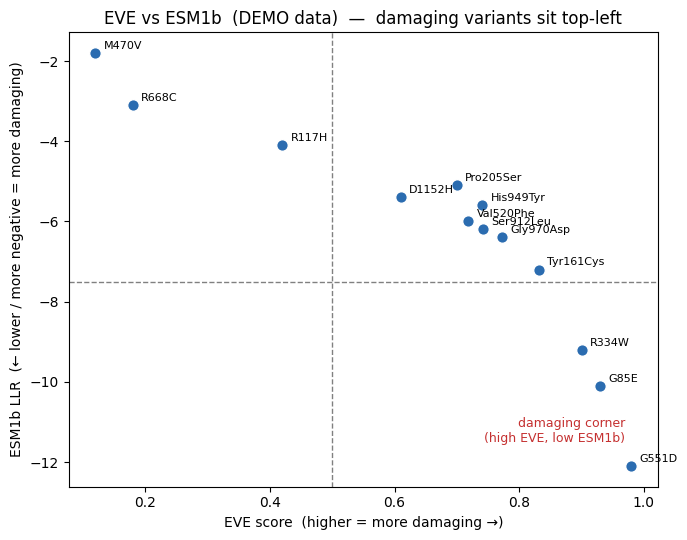

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(calls['eve_score'], calls['esm1b_score'],
           s=70, color='#2b6cb0', edgecolor='white', zorder=3)

# Label each point with its variant name.
for _, r in calls.iterrows():
    ax.annotate(r['protein_variant'], (r['eve_score'], r['esm1b_score']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

# Threshold guides.
ax.axvline(tk.THRESHOLDS['eve']['path'],   ls='--', color='grey', lw=1)
ax.axhline(tk.THRESHOLDS['esm1b']['path'], ls='--', color='grey', lw=1)

ax.set_xlabel('EVE score  (higher = more damaging \u2192)')
ax.set_ylabel('ESM1b LLR  (\u2190 lower / more negative = more damaging)')
ax.set_title('EVE vs ESM1b  (DEMO data)  \u2014  damaging variants sit top-left')
ax.annotate('damaging corner\n(high EVE, low ESM1b)', xy=(0.97, -11.5),
            ha='right', fontsize=9, color='#c53030')
fig.tight_layout()
plt.show()

## 6 · Why "unsupervised" matters — a teaser for benchmarking

Here is the payoff of the fact we flagged at the very top. **Neither EVE nor ESM1b was trained on clinical *pathogenic / benign* labels.** EVE learned from evolutionary alignments; ESM1b learned from raw protein sequences. They discovered constraint on their own.

That makes them **safer to benchmark against ClinVar** than a *supervised* tool like **REVEL** (coming up in notebooks 04 and 08). REVEL was *trained* on curated pathogenic/benign variants whose lineage overlaps ClinVar and HGMD. So when REVEL "agrees" with ClinVar, some of that agreement is **circular** — the answer partly leaked into the training data. When *EVE* agrees with ClinVar, that agreement is genuinely independent evidence.

| Predictor | Learns from | Trained on clinical labels? | Circularity vs ClinVar |
|-----------|-------------|-----------------------------|------------------------|
| **EVE** | multiple-sequence alignments | ❌ no | **low** |
| **ESM1b** | raw protein sequences | ❌ no | **low** |
| **REVEL** | curated pathogenic/benign sets | ✅ yes | **high** |

We quantify this properly in **notebook 08**. For now, just remember: *how a predictor learned* decides *how you are allowed to test it.*

## Key takeaways

1. **EVE** = a generative model of a protein family's **evolutionary** variation (its MSA). Score in `[0, 1]`, `>= 0.5` ~ pathogenic, **higher = worse**.
2. **ESM1b** = a **protein language model**; it scores the **log-likelihood ratio** of mutant vs wild-type amino acid. Cut `<= -7.5` ~ pathogenic — **lower / more negative = worse** (the *opposite* direction to EVE).
3. `tk.call_from_score(score, tool)` bakes in each tool's threshold **and direction**, so you get consistent `pathogenic / uncertain / benign` calls without juggling signs yourself.
4. On an EVE-vs-ESM1b scatter, the truly damaging variants land in the **high-EVE / low-ESM1b** (top-left) corner.
5. Both tools are **unsupervised** w.r.t. clinical labels → **low circularity**, which makes them fairer to benchmark against ClinVar than a supervised ensemble like REVEL.
6. **Everything here is DEMO data.** Swap in real EVE (evemodel.org, UniProt P13569) and ESM1b (Brandes 2023 supplement / HuggingFace) files, join on `protein_variant`, and every cell above runs unchanged.

**Next:** notebook 04 introduces **REVEL** — a *supervised* ensemble — and sets up the circularity discussion this notebook previewed.